In [26]:
import pandas as pd
import numpy as np
import re
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [27]:
file_path = "C:/Users/mella/OneDrive/Desktop/Master's/ESCI 620-01/Ocean Acidification Project/OCEAN_ACIDIFICATION_RAW_20260328.xlsx"
ocean_acidification = pd.read_excel(file_path)

In [28]:
print(ocean_acidification.head())
print(ocean_acidification.isnull().sum())

        Site Id Year_Season  Calcium (Dissolved) mg/L  \
0  Weeki Wachee      1993_4                      52.0   
1  Weeki Wachee      1994_3                      54.5   
2  Weeki Wachee      1994_4                      50.0   
3  Weeki Wachee      1995_1                      55.0   
4  Weeki Wachee      1995_2                      54.0   

   Nitrate-Nitrite (N) mg/L  pH (Total) SU  Alkalinity (Total) umol/kg  \
0                     0.400          7.565                 2590.844010   
1                     0.285          7.600                 2810.189649   
2                     0.542          7.410                 2680.676085   
3                     0.414          7.620                 2770.980289   
4                     0.474          7.560                 2730.978060   

   Temperature (Total) Deg. C  Salinity (psu)  Atmospheric CO2 (ppm)  \
0                        24.3            0.15                 354.13   
1                        24.1            0.15                 359.39

In [29]:
#Standardize column names 
ocean_acidification.columns = [
    re.sub(r"\s+", "_", c.strip())
     .replace("/", "_")
     .replace("(", "")
     .replace(")", "")
    for c in ocean_acidification.columns
]

#Replace the -9999 values with a missing label
ocean_acidification = ocean_acidification.replace(-9999, np.nan)

#Separate year and season into two columns and changing type to int
if "Year_Season" in ocean_acidification.columns:
    ys = ocean_acidification["Year_Season"].astype(str).str.extract(r"(?P<Year>\d{4})[_-]?(?P<Season>\d+)")
    ocean_acidification["Year"] = pd.to_numeric(ys["Year"], errors="coerce").astype("Int64")
    ocean_acidification["Season"] = pd.to_numeric(ys["Season"], errors="coerce").astype("Int64")
    ocean_acidification = ocean_acidification.drop(columns=["Year_Season"])

#Remove white space from text columns
for c in ocean_acidification.select_dtypes(include="object").columns:
    ocean_acidification[c] = ocean_acidification[c].astype(str).str.strip()

ocean_acidification = ocean_acidification.sort_values(["Site_Id", "Year", "Season"], na_position="last").reset_index(drop=True)

#Search for duplicates and drop them
exact_dups = ocean_acidification.duplicated().sum()
key_dups = ocean_acidification.duplicated(subset=["Site_Id", "Year", "Season"]).sum()

num_cols = ['Calcium_Dissolved_mg_L', 'Nitrate-Nitrite_N_mg_L', 'pH_Total_SU', 
            'Alkalinity_Total_umol_kg', 'Temperature_Total_Deg._C', 'Salinity_psu',
            'Atmospheric_CO2_ppm', 'Wind_AVG_mph', 'pCO2_microatm', 'CO2_Flux_mmol_m2_d']

#Flag outliers
ocean_acidification["flags"] = ""
for col in num_cols:
    Q1 = ocean_acidification[col].quantile(0.25)
    Q3 = ocean_acidification[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ocean_acidification[(ocean_acidification[col] < lower) | (ocean_acidification[col] > upper)].index
    for idx in outliers:
        ocean_acidification.at[idx, "flags"] += f"{col}_outlier; "

ocean_acidification = ocean_acidification.sort_values(["Site_Id", "Year", "Season"], na_position="last").reset_index(drop=True)

os.makedirs('output/managed', exist_ok=True)

# Site-specific MAD flagging (±3*MAD from median)
ocean_acidification_managed = ocean_acidification.copy()
ocean_acidification_managed['mad_flags'] = ''

site_stats = {}
for site in ocean_acidification['Site_Id'].unique():
    site_mask = ocean_acidification['Site_Id'] == site
    site_data = ocean_acidification.loc[site_mask, num_cols]
    stats = {}
    
    for col in num_cols:
        vals = site_data[col].dropna()
        if len(vals) > 3:
            med = vals.median()
            mad = np.median(np.abs(vals - med))
            lower = med - 3 * mad
            upper = med + 3 * mad
            stats[col] = {'median': float(med), 'mad': float(mad), 
                         'lower': float(lower), 'upper': float(upper)}
            
            # Flag site-specific outliers
            outliers = ocean_acidification.loc[site_mask & 
                             ((ocean_acidification[col] < lower) | (ocean_acidification[col] > upper)), col].index
            for idx in outliers:
                ocean_acidification_managed.at[idx, 'mad_flags'] += f"{col}_mad; "
    
    site_stats[site] = stats

# Robust summary statistics by site
robust_stats = ocean_acidification.groupby('Site_Id')[num_cols].agg(['median', 'count']).round(2)

# Save outputs
ocean_acidification_managed.to_csv('OCEAN_ACIDIFICATION_CLEANED_20260405.csv', index=False)
robust_stats.to_csv('OCEAN_ACIDIFICATION_ROBUST_STATS_20260405.csv')


In [30]:
# Descriptive Stats
print(ocean_acidification.describe().round(2))
median = ocean_acidification.median(numeric_only = True)
print(f'Median:\n{median}')

# IQR
first = ocean_acidification.quantile(0.25, numeric_only = True)
third = ocean_acidification.quantile(0.75, numeric_only = True)
IQR = third - first
print(f'IQR:\n{IQR}')

# Calculate Skew
print(f'Skew:\n{ocean_acidification.skew(numeric_only = True)}')

# Calculate Correlation Matrix for data
correlation = ocean_acidification.corr(numeric_only = True)
print(correlation)

       Calcium_Dissolved_mg_L  Nitrate-Nitrite_N_mg_L  pH_Total_SU  \
count                  406.00                  404.00       406.00   
mean                    72.27                    0.62         7.46   
std                     47.31                    0.40         0.18   
min                     30.15                    0.00         7.00   
25%                     44.18                    0.40         7.32   
50%                     54.26                    0.52         7.45   
75%                     79.38                    0.66         7.58   
max                    316.00                    1.85         8.00   

       Alkalinity_Total_umol_kg  Temperature_Total_Deg._C  Salinity_psu  \
count                    406.00                    406.00        406.00   
mean                    2425.12                     23.39          2.31   
std                      419.43                      0.79          3.64   
min                     1197.02                     17.84          0.

In [31]:
# Remove coast and river sites 
site_filter = ~ocean_acidification['Site_Id'].str.contains('COAST|RIVER', case = False, na = False)
plot_df = ocean_acidification[site_filter][['Site_Id', 'Year',
                  'pH_Total_SU', 'Alkalinity_Total_umol_kg', 
                  'Temperature_Total_Deg._C',
                  'CO2_Flux_mmol_m2_d']].copy()

# Recode the Variable column to your desired labels
var_mapping = {
    'Total pH': 'Total pH',
    'Total Alkalinity': 'Total Alkalinity',
    'Total Temperature': 'Total Temperature',
    'Carbon Flux Band E': 'Carbon Flux',
    'Carbon Flux Band S': 'Carbon Flux'
}

df_long = plot_df.melt(
    id_vars = ['Site_Id', 'Year'],
    value_vars = ['pH_Total_SU', 'Alkalinity_Total_umol_kg', 
                  'Temperature_Total_Deg._C', 
                   'CO2_Flux_mmol_m2_d'],
    var_name = 'Variable',
    value_name = 'Value').copy()

# Apply mapping (keep original if not in mapping)
df_long['Variable'] = df_long['Variable'].map(var_mapping).fillna(df_long['Variable'])

# Your existing plot
g = sns.relplot(
    data = df_long,
    kind = 'line',
    x = 'Year',
    y = 'Value',
    hue = 'Site_Id',
    col = 'Variable',
    col_wrap = 2,
    style = 'Site_Id',
    height = 4,
    aspect = 1.5,
    facet_kws = {'sharey': False},
    errorbar = None
)

# Set y‑axis labels to match the variable names
ylabels = {
    'Total pH': 'Total pH',
    'Total Alkalinity': 'Total Alkalinity',
    'Total Temperature': 'Total Temperature',
    'Carbon Flux': 'Carbon Flux'
}

for ax in g.axes.flat:
    title = ax.get_title()
    if 'Variable = ' in title:
        var_key = title.split('Variable = ')[1]
    else:
        var_key = title

    if var_key in ylabels:
        ax.set_ylabel(ylabels[var_key])
    else:
        ax.set_ylabel(var_key)

    ax.set_xlabel('Year')

# Add figure-wide title
g.fig.suptitle('Variables over time for each site', fontsize=16, y=1.02)


# Save
plt.savefig('ocean_acidification_multifaceted_plots.jpg', dpi=300, bbox_inches='tight')
plt.close()

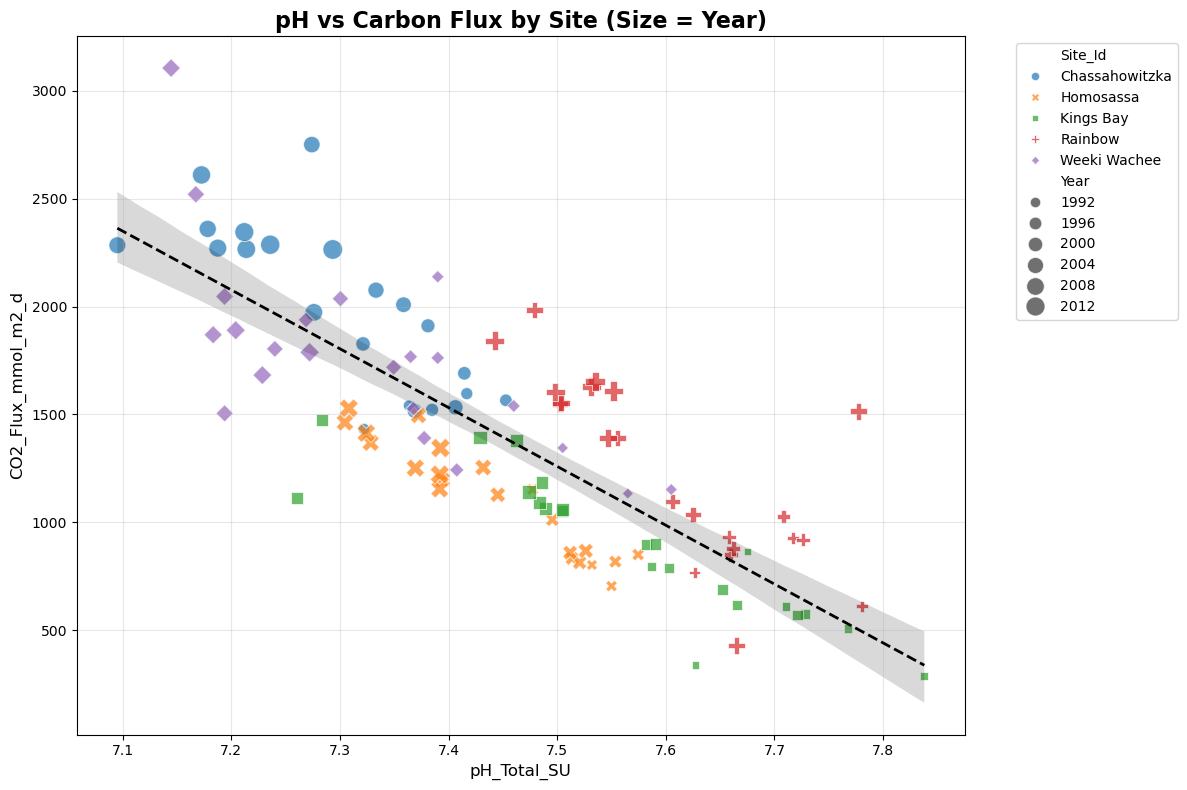

-0.8192539091640626


In [32]:
# Format data for scatterplot with carbon flux and pH at sites
scatter_df = df_long[df_long['Variable'].isin(['pH_Total_SU', 'CO2_Flux_mmol_m2_d'])].copy()

pivot_scatter = scatter_df.pivot_table(index = ['Site_Id', 'Year'],
                                 columns = 'Variable', values = 'Value',
                                aggfunc = 'mean').reset_index()

pivot_scatter['pH_Total_SU'] = pivot_scatter['pH_Total_SU'].astype('float64')
pivot_scatter['CO2_Flux_mmol_m2_d'] = pivot_scatter['CO2_Flux_mmol_m2_d'].astype('float64')
pivot_scatter['Year'] = pivot_scatter['Year'].astype('float64')

# Create scatter plot visualizing connection between pH and Carbon flux
plt.figure(figsize=(12, 8))
sns.scatterplot(data=pivot_scatter, x='pH_Total_SU', y='CO2_Flux_mmol_m2_d', 
                hue='Site_Id', style='Site_Id', size='Year',
                sizes=(50, 200), alpha=0.7, palette='tab10')

plt.title('pH vs Carbon Flux by Site (Size = Year)', fontsize=16, fontweight='bold')
plt.xlabel('pH (Total Scale)', fontsize=12)
plt.ylabel('CO2 Flux (mmol/m²/d)', fontsize=12)
plt.grid(True, alpha=0.3)

# Add trend line
sns.regplot(data=pivot_scatter, x='pH_Total_SU', y='CO2_Flux_mmol_m2_d', 
            scatter=False, color='black', line_kws={'linestyle':'--', 'linewidth':2})

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('ocean_acidification_scatter.jpg')
plt.show()

# Identify correlation between pH and carbon flux
corr = pivot_scatter['pH_Total_SU'].corr(pivot_scatter['CO2_Flux_mmol_m2_d'])
print(corr)



In [33]:
#Create Multiple Regression Model by Site ID
model_df = pd.read_csv("C:/Users/mella/OneDrive/Desktop/Master's/ESCI 620-01/Ocean Acidification Project/OCEAN_ACIDIFICATION_CLEANED_20260405.csv")

#Define features and target
target = 'pH_Total_SU'
predictors = ['CO2_Flux_mmol_m2_d', 'Alkalinity_Total_umol_kg', 
              'pCO2_microatm', 'Temperature_Total_Deg._C', 'Salinity_psu', 'Site_Id']

#Clean data - drop rows missing target or key predictors
df_clean = model_df.dropna(subset=[target] + predictors[:-1])  
print(f"Dataset shape after cleaning: {df_clean.shape}")

# Separate features and target
X = df_clean[predictors]
y = df_clean[target]

#Split into training and testing sets by site ID
X_train, X_test, y_train, y_test, sites_train, sites_test = train_test_split(
    X, y, df_clean['Site_Id'], 
    test_size=0.2, 
    random_state=42,
    stratify=df_clean['Site_Id']  # Ensures proportional site representation
)

print(f"Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test:  {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print("\nSite distribution check:")
print("Train:", X_train['Site_Id'].value_counts().sort_index())
print("Test: ", X_test['Site_Id'].value_counts().sort_index())

#Preprocess
numeric_features = ['CO2_Flux_mmol_m2_d', 'Alkalinity_Total_umol_kg', 
                   'pCO2_microatm', 'Temperature_Total_Deg._C', 'Salinity_psu']
categorical_features = ['Site_Id']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nProcessed feature shapes: Train={X_train_processed.shape}, Test={X_test_processed.shape}")

# Train model
model = LinearRegression()
model.fit(X_train_processed, y_train)

# Evaluate on test set
y_test_pred = model.predict(X_test_processed)

print("\n" + "="*50)
print("MODEL PERFORMANCE")
print("="*50)
print(f"Train R²: {r2_score(y_train, model.predict(X_train_processed)):.4f}")
print(f"Test  R²: {r2_score(y_test, y_test_pred):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")

#Feature Importance
feature_names = (numeric_features + 
                list(preprocessor.named_transformers_['cat'].get_feature_names_out()))
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)
print("\nTop 5 Most Important Features:")
print(coef_df.head())

Dataset shape after cleaning: (406, 15)
Train: 324 (79.8%)
Test:  82 (20.2%)

Site distribution check:
Train: Site_Id
Chassahowitzka       61
HOMOSASSA COAST 1     4
HOMOSASSA COAST 2     4
HOMOSASSA RIVER       4
Homosassa            64
Kings Bay            62
Rainbow              61
Weeki Wachee         64
Name: count, dtype: int64
Test:  Site_Id
Chassahowitzka       16
HOMOSASSA COAST 1     1
HOMOSASSA COAST 2     1
HOMOSASSA RIVER       1
Homosassa            16
Kings Bay            16
Rainbow              15
Weeki Wachee         16
Name: count, dtype: int64

Processed feature shapes: Train=(324, 12), Test=(82, 12)

MODEL PERFORMANCE
Train R²: 0.8246
Test  R²: 0.7698
Test RMSE: 0.0927

Top 5 Most Important Features:
                     feature  coefficient
6  Site_Id_HOMOSASSA COAST 2     0.653858
5  Site_Id_HOMOSASSA COAST 1     0.379766
8          Site_Id_Homosassa    -0.134505
2              pCO2_microatm    -0.077518
4               Salinity_psu    -0.074521


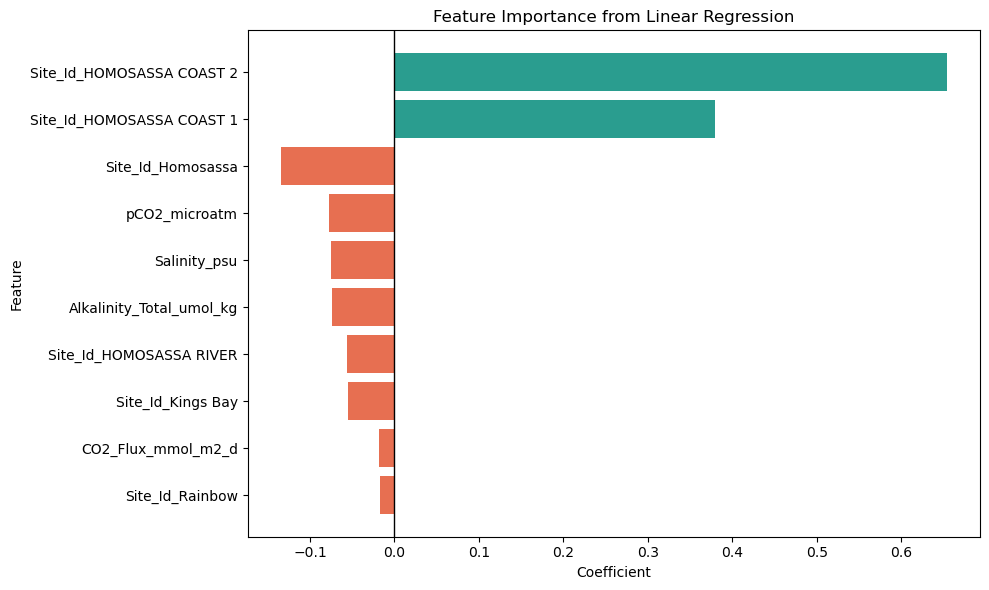

In [41]:
model = LinearRegression()
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

pipe.fit(X_train, y_train)

cat_names = pipe.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_names)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": pipe.named_steps["model"].coef_
})
coef_df["importance"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("importance", ascending=False)

plot_df = coef_df.head(10).sort_values("importance")

plt.figure(figsize=(10, 6))
colors = ["#2a9d8f" if c > 0 else "#e76f51" for c in plot_df["coefficient"]]
plt.barh(plot_df["feature"], plot_df["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Feature Importance from Linear Regression")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("output/feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()